In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.callbacks import Callback

# 1. Load the dataset
text_data = [
    "machine learning models learn patterns from data.",
    "sequence models process data step by step.",
    "recurrent neural networks are designed for sequential tasks.",
    "rnn models maintain hidden states across time steps.",
    "long short term memory networks solve long dependency problems.",
    "lstm uses gates to control information flow.",
    "gru models simplify the lstm architecture.",
    "sequence prediction is useful in many applications.",
    "language modeling predicts the next word in a sentence.",
    "speech recognition processes audio sequences.",
    "time series forecasting predicts future values.",
    "music generation creates new melodies.",
    "generative models learn probability distributions.",
    "they generate new samples similar to training data.",
    "sequence generation is widely used in artificial intelligence.",
    "deep learning improves sequence modeling performance."
]

# 2. Tokenization and Numerical Representation
tokenizer = Tokenizer()
tokenizer.fit_on_texts(text_data)
total_words = len(tokenizer.word_index) + 1

# Create an O(1) lookup dictionary for word generation later
index_to_word = tokenizer.index_word

# 3. Create input-output sequence pairs (N-gram approach)
input_sequences = []
for line in text_data:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

# Pad sequences to ensure uniform length
max_sequence_len = max([len(seq) for seq in input_sequences])
input_sequences = pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')

# Split into predictors (X) and label (y)
X, y = input_sequences[:,:-1], input_sequences[:,-1]
y = tf.keras.utils.to_categorical(y, num_classes=total_words)

# 4. Design the LSTM-based generative model (Modern Keras syntax)
model_lstm = Sequential([
    Input(shape=(max_sequence_len-1,)),
    Embedding(input_dim=total_words, output_dim=64),
    LSTM(100, return_sequences=False),
    Dense(total_words, activation='softmax')
])

model_lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_lstm.summary()

# Custom Callback to keep the training output quiet and neat
class PrintEveryNEpochs(Callback):
    def __init__(self, interval=20):
        self.interval = interval

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.interval == 0:
            print(f"Epoch [{epoch+1}/100], Loss: {logs['loss']:.4f}, Accuracy: {logs['accuracy']:.4f}")

# 5. Train the model
print("\n--- Training LSTM Model ---")
# Set verbose=0 to turn off the default Keras progress bar, and use our custom callback
# 5. Train the model and save history
print("\n--- Training LSTM Model ---")
history_lstm = model_lstm.fit(X, y, epochs=100, verbose=0, callbacks=[PrintEveryNEpochs(interval=20)])

# 6. Generate new sequences using a seed input
def generate_sequence(seed_text, next_words, model, max_seq_len):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')

        # Predict the probabilities for the next word
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_word_index = np.argmax(predicted_probs, axis=-1)[0]

        # O(1) dictionary lookup instead of a loop
        output_word = index_to_word.get(predicted_word_index, "")

        seed_text += " " + output_word
    return seed_text

print("\n--- LSTM Generated Output ---")
seed = "sequence models"
print(f"Seed: '{seed}' -> Generated: {generate_sequence(seed, 5, model_lstm, max_sequence_len)}")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 8, 64)          │         5,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 87)             │         8,787 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,355 (313.89 KB)

 Trainable params: 80,355 (313.89 KB)

 Non-trainable params: 0 (0.00 B)


--- Training LSTM Model ---

--- Training LSTM Model ---
Epoch [20/100], Loss: 3.8506, Accuracy: 0.1368
Epoch [40/100], Loss: 2.4688, Accuracy: 0.4105
Epoch [60/100], Loss: 1.5369, Accuracy: 0.7474
Epoch [80/100], Loss: 1.0171, Accuracy: 0.8211
Epoch [100/100], Loss: 0.7118, Accuracy: 0.9053

--- LSTM Generated Output ---
Seed: 'sequence models' -> Generated: sequence models process data step by step


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_4  │ (None, 8, 64)          │         6,080 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 8, 64)          │        50,048 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 87)             │         5,655 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,943 (257.59 KB)

 Trainable params: 65,943 (257.59 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Transformer Model ---
Epoch [20/100], Loss: 2.9940, Accuracy: 0.2947
Epoch [40/100], Loss: 1.1449, Accuracy: 0.7579
Epoch [60/100], Loss: 0.2698, Accuracy: 0.9789
Epoch [80/100], Loss: 0.1166, Accuracy: 0.9789
Epoch [100/100], Loss: 0.0858, Accuracy: 0.9789

--- Transformer Generated Output ---
Seed: 'generative models' -> Generated: generative models learn probability distributions distributions distributions


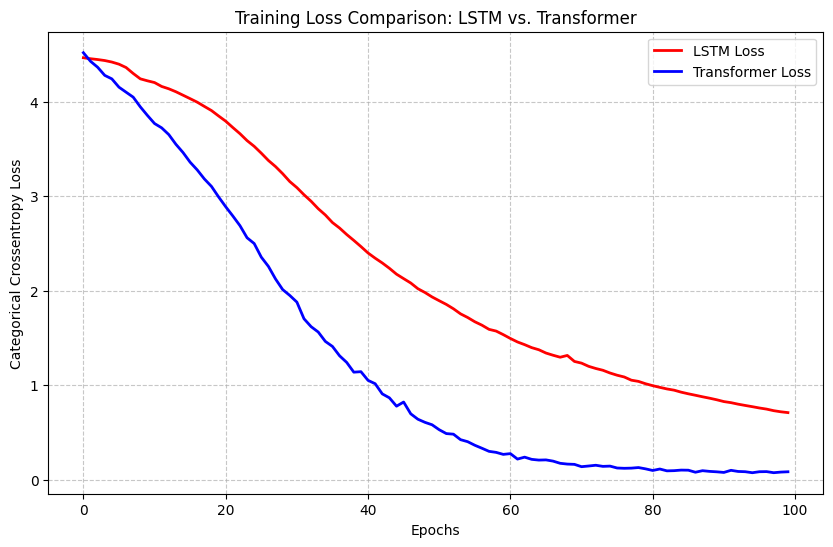

In [9]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Custom Layer for Positional Encoding & Token Embedding
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

# Custom Layer for a single Transformer Block
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        # Self-attention
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        # Feed Forward
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Model Parameters
embed_dim = 64  # Embedding size for each token
num_heads = 2   # Number of attention heads
ff_dim = 128    # Hidden layer size in feed forward network inside transformer

# Build the Transformer model using Keras Functional API
inputs = layers.Input(shape=(max_sequence_len-1,))
embedding_layer = TokenAndPositionEmbedding(max_sequence_len-1, total_words, embed_dim)
x = embedding_layer(inputs)
transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)
x = transformer_block(x)
x = layers.GlobalAveragePooling1D()(x) # Pool sequence to predict the next word
x = layers.Dropout(0.1)(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(total_words, activation="softmax")(x)

model_transformer = tf.keras.Model(inputs=inputs, outputs=outputs)
model_transformer.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model_transformer.summary()

# Train the Transformer and save history for plotting
print("\n--- Training Transformer Model ---")
history_transformer = model_transformer.fit(
    X, y,
    epochs=100,
    verbose=0,
    callbacks=[PrintEveryNEpochs(interval=20)] # Reusing the callback from Component I
)

# Generate sequences
print("\n--- Transformer Generated Output ---")
seed2 = "generative models"
print(f"Seed: '{seed2}' -> Generated: {generate_sequence(seed2, 5, model_transformer, max_sequence_len)}")

# Plot the Loss Graph for BOTH models
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['loss'], label='LSTM Loss', color='red', linewidth=2)
plt.plot(history_transformer.history['loss'], label='Transformer Loss', color='blue', linewidth=2)
plt.title('Training Loss Comparison: LSTM vs. Transformer')
plt.xlabel('Epochs')
plt.ylabel('Categorical Crossentropy Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()